# Spectroscopic Data Reduction Part 3: Extracting the final wavelength-calibrated spectrum 

This tutorial assumes you have gone through the [Trace](1-SpectroscopicTraceTutorial.ipynb) and [Wavelength Calibration](2-WavelengthCalibration) tutorials and have their results available.

## Authors
Adam Ginsburg, Kelle Cruz, Lia Corrales, Jonathan Sick, Adrian Price-Whelan

## Learning Goals
* Extract a target 1D spectrum from a two-dimensional spectrum using an existing trace
* Apply a fitted wavelength solution to the data
* Fit a line profile to the wavelength-calibrated spectrum

## Keywords
Spectroscopy

## Summary
This tutorial, the third in a series, shows how to apply a trace and a wavelength solution to science data.  It then shows how to do basic analysis, i.e., line fitting.

In [ ]:
with open('requirements.txt') as f:
    print(f"Required packages for this notebook:\n{f.read()}")

## Extract the science spectrum

First, we repeat the trace-and-extract process derived in [Part 1](1-SpectroscopicTraceTutorial.ipynb), but now for Deneb:

In [1]:
from PIL import Image as PILImage
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

In [2]:
from astropy.modeling.models import Linear1D
from astropy import constants
from astropy import units as u
from astropy.visualization import quantity_support
quantity_support() # activar soporte de unidades

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x7f95a13ed510>

In [3]:
image_array_2 = np.array(PILImage.open('deneb_3s_1.bmp'))
print(image_array_2.shape)

(1200, 1600)


In [4]:
from astropy.modeling.polynomial import Polynomial1D
from astropy.modeling.models import Gaussian1D
from astropy.modeling.fitting import LevMarLSQFitter, LinearLSQFitter
linfitter = LinearLSQFitter()

In [5]:
yaxis2 = np.repeat(np.arange(470, 520)[:,None], image_array_2.shape[1], axis=1)
xvals = np.arange(image_array_2.shape[1])
weighted_yaxis_values2 = np.average(yaxis2, axis=0, weights=image_array_2[470:520,:] - np.median(image_array_2))
polymodel2 = Polynomial1D(degree=3)
fitted_polymodel2 = linfitter(polymodel2, xvals, weighted_yaxis_values2)
trace_center2 = fitted_polymodel2(xvals)

In [6]:
npixels_to_cut = 15
trace_center = fitted_polymodel2(xvals)
cutouts = np.array([image_array_2[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii]
                    for yval, ii in zip(trace_center, xvals)])
cutouts.shape
mean_trace_profile = cutouts.mean(axis=0)

In [7]:
spectrum2 = np.array([np.average(image_array_2[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=mean_trace_profile)
                     for yval, ii in zip(trace_center2, xvals)])

Next, we retrieve the wavelength solution derived in Part 2.

In [8]:
wlmodel = Linear1D(slope=-0.10213643, intercept=562.3862495)

In [9]:
wavelengths = wlmodel(xvals) * u.nm

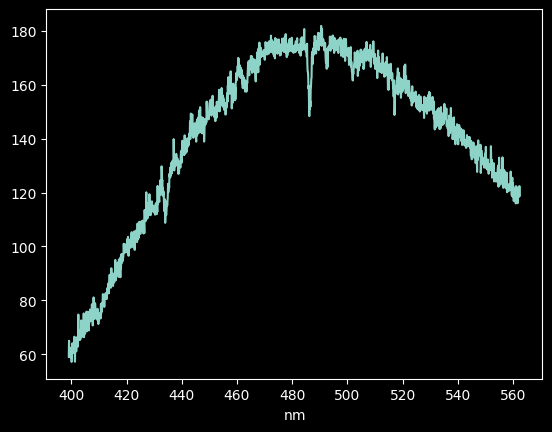

In [10]:
plt.plot(wavelengths, spectrum2)

# Analysis

Now, we go on to do some basic analysis on our fully extracted and wavelength-calibrated spectrum

We zoom in on the 4860 Angstrom line - H-Beta

(np.float64(470.0), np.float64(510.0), np.float64(140.0), np.float64(190.0))

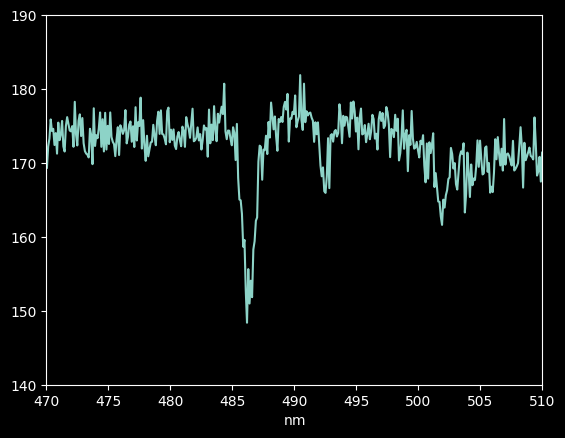

In [11]:
plt.plot(wavelengths, spectrum2)
plt.axis([470,510,140,190])

We can use astropy models to construct an absorption line model, consisting of a continuum level and a negative Gaussian to represent the absorption feature

In [12]:
absorption_model_guess = Linear1D(slope=0, intercept=175) + Gaussian1D(amplitude=-25, mean=486, stddev=2)

We can overplot our guessed model - it's not right, but it's in the right spot

(np.float64(470.0), np.float64(510.0), np.float64(140.0), np.float64(190.0))

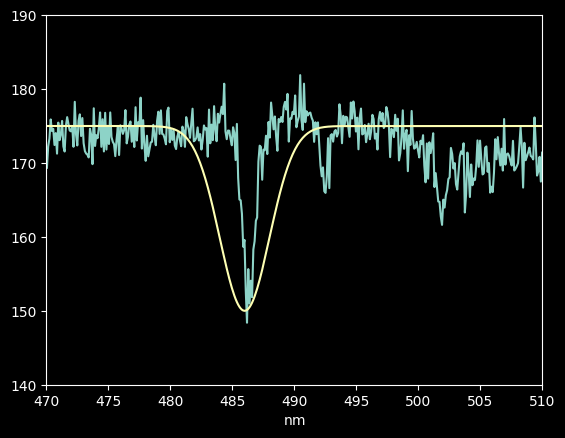

In [13]:
plt.plot(wavelengths, spectrum2)
plt.plot(wavelengths, absorption_model_guess(wavelengths.value))
plt.axis([470,510,140,190])

The Levenberg-Marquardt Least Squares fitter can be used to find the optimal fit to our data given the starting guess.

In [14]:
lmfitter = LevMarLSQFitter()
selection = (wavelengths > 470*u.nm) & (wavelengths < 500*u.nm) 
fitted_absorption_model = lmfitter(model=absorption_model_guess, x=wavelengths.value[selection], y=spectrum2[selection])

(np.float64(470.0), np.float64(510.0), np.float64(140.0), np.float64(190.0))

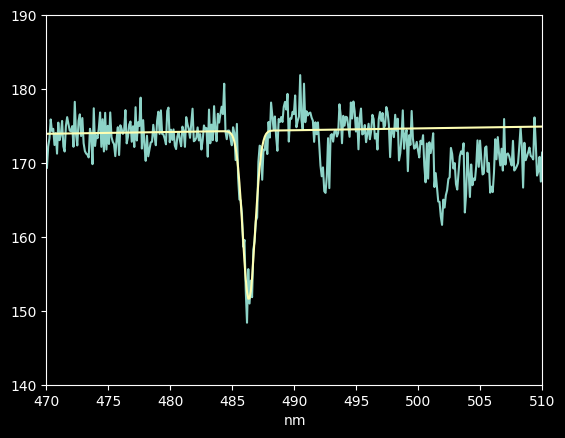

In [15]:
plt.plot(wavelengths, spectrum2)
plt.plot(wavelengths, fitted_absorption_model(wavelengths.value))
plt.axis([470,510,140,190])

That's it!  You've extracted and wavelength-calibrated a spectrum.

## Ejercicio

1) Realizar el mismo procedimiento de calibración para el espectro de:
    
    a) aldebaran
    
    b) vega de la lyra